# DC-EGM Under The Hood

## Dependencies, Packages & Roots

In [21]:
%reload_ext autoreload
%autoreload 2

In [22]:
from pathlib import Path
import sys
import importlib

# Change this depending on notebook location:
# 0 = notebook is 1 folder inside project root, e.g. dp_termpaper/edu1
# 1 = notebook is 2 folders inside project root, e.g. dp_termpaper/data/moments
# 2 = notebook is 3 folders inside project root
amount_of_levels = 0

DIR = Path.cwd().resolve().parents[amount_of_levels]

if str(DIR) not in sys.path:
    sys.path.insert(0, str(DIR))

import project_paths as pp
from project_imports import *

importlib.reload(pp)
jax.config.update("jax_enable_x64", True)

### Determine Macros

In [23]:
###############################################################
#### Define which education level you want to estimate for ####
###############################################################

education_level = "edu1"
# education_level = "edu2"
# education_level = "edu3"

# Amount of individuals in simulated sample
n_sim = 1
n_individuals = 100_000

# Whether to run the structural estimation or just load the results
structural_estimation = False

### Load Data


In [24]:
education_level_file = pp.MOMENTS_DIR / f"moments_{education_level}.txt"
MORTALITY = pp.DATA_DIR / "mortality.xlsx"
beta0, beta1, beta2 = np.loadtxt(pp.FIRST_STAGE_RESULTS_DIR / f"wage_params_{education_level}_ols.txt")
alpha1, alpha2 = np.loadtxt(pp.STRUCTURAL_RESULTS_DIR/ "mortality_params.txt")

# Read CSV
df_edu = pd.read_csv(education_level_file)
# read mortality and discard seoncd and third column
df_mort = pd.read_excel(MORTALITY, sheet_name="DOD", usecols=[0, 3])

# 2) standardize colomn name and remove _FREQ_ column
# Iterate over DataFrames (if there are multiple DataFrames to process)
for data_frame in [df_edu]:
    # Rename ALDER → age
    if "ALDER" in data_frame.columns:
        data_frame.rename(columns={"ALDER": "age"}, inplace=True)
    # Remove _FREQ_-column if it exists
    # if "_FREQ_" in data_frame.columns:
    #     data_frame.drop(columns=["_FREQ_"], inplace=True)
# drop var_wage, skew_wage and pens
df_edu.drop(columns=["var_wage", "skew_wage", "pens"], errors="ignore", inplace=True)
# df_edu

## Initiatal parameters

In [25]:
params_initial = load_params_txt(pp.STRUCTURAL_RESULTS_DIR / f"optimized_params_phi_{education_level}.txt")
params_initial["gamma"] = jnp.asarray(params_initial["gamma"])

## Options for model - Choices and states

In [26]:
n_periods = 55
labour_choices = np.arange(5) # 5 choices

model_config = {
    "n_periods": n_periods,
    "choices": labour_choices, # 5 choices
    "n_quad_points": 5,
    "continuous_states": {
        "assets_end_of_period": np.linspace(0, 50, 200),
        "experience": jnp.linspace(0, 1, 5).astype(float) # 1 experince grid point, if experience can only go up by a year - more points if it is a fraction based on hours worked
        },
    "stochastic_states": {
        "survival": [0, 1],
    }
    }

model_specs = {
    "choices": labour_choices, # 5 choices
    "n_periods": n_periods,
    "labour_choices": labour_choices, # 5 choices
    "hours": jnp.array([0,250,750,1300,1900]), #list 
    "max_hours": 1900,
    "start_age": 30,
    "tax_threshold1": 0.480,
    "tax_threshold2": 5.698,
    "tax_base_rate": 0.38,
    "tax_top_rate": 0.5,
    "retirement_age": 67,
    "oap_base_amount": 0.80328,
    "oap_max_supplement": 0.92940,
    "supp_threshold": 0.79300,
    "oap_threshold": 3.3592,
    "supp_reduction_rate": 0.309,
    "oap_reduction_rate": 0.3,
    "alpha1": alpha1, # independently estimated parameter for survival probability
    "alpha2": alpha2,  # independently estimated parameter for survival probability
    "max_init_experience": 5,
    "max_ret_period": 45, # Age 75
    "min_ret_period": 30, # Age 60
}
stochastic_states_transitions = {
    "survival": prob_survival
}

### Setup the model

In [27]:
model = dcegm.setup_model(
    model_config=model_config,
    model_specs=model_specs,
    utility_functions=new_utility_functions,
    utility_functions_final_period=final_period_utility,
    budget_constraint=budget_dcegm_initial,
    state_space_functions=create_state_space_function_dict(),
    stochastic_states_transitions=stochastic_states_transitions,
)

Starting state space creation
State space created.

Starting state-choice space creation and child state mapping.
State, state-choice and child state mapping created.

Start creating batches for the model.
The batch size of the backwards induction is  25
Model setup complete.



### Initial values for simulating

In [28]:
seed = 132
key = jax.random.PRNGKey(0)
n = n_individuals       

# hours mapping for simulation
hours_map = {0: 0, 1: 250, 2: 750, 3: 1300, 4: 1900}

#age for simulation
start_age = model_specs["start_age"] 

# distribution of initial choices
labels = jnp.array([0, 1, 2, 3, 4], dtype=jnp.int32)
probs  = jnp.array([0.259155, 0.118310, 0.108099, 0.108451, 0.405986])  # sums to 1.0

lagged_choice = jax.random.choice(
    key,
    a       = labels,
    shape   = (n,),
    p       = probs,
    replace = True
)

# set initial states for each individual
states_initial = {
    "period": jnp.zeros(n_individuals, dtype=jnp.int32),      # Every individual starts at period 0 (age 30)
    "lagged_choice": lagged_choice,  # Every individual starts with choice 3 (work fulltime)
    "experience": jnp.full(n_individuals, 1).astype(float),  # Every individual starts with 5 years of experience
    "survival": jnp.ones(n_individuals, dtype=jnp.int32), # Every individual starts with 1 (alive)
    "assets_begin_of_period": jnp.full(n_individuals, 0.505047) # Every individual starts with 59k wealth - to be adjusted based on the actual moments
}

### Initiatal parameters

In [29]:
params_initial = load_params_txt(pp.STRUCTURAL_RESULTS_DIR / f"optimized_params_phi_{education_level}.txt")
params_initial["gamma"] = jnp.asarray(params_initial["gamma"])

In [30]:
model_solved = model.solve(params_initial)

In [31]:
model.validate_exogenous(params_initial)

True

### Slicing the solved dataset

In [32]:
# Main plotting choices
ages_to_plot = [35, 45, 55, 65, 75]
lagged_choices_to_plot = [0, 2, 4]
survival_to_plot = 1

# Your experience grid from model_config:
experience_grid = np.asarray(model_config["continuous_states"]["experience"], dtype=float)

experience_slices = {
    "low experience": experience_grid[0],
    "median experience": experience_grid[len(experience_grid) // 2],
    "high experience": experience_grid[-1],
}

labour_choices = np.asarray(model_specs["labour_choices"])
hours = np.asarray(model_specs["hours"])
hours_map = dict(zip(labour_choices, hours))

start_age = model_specs["start_age"]

In [33]:
def inspect_solved_model(obj, name="model_solved", max_depth=3):
    rows = []

    def walk(x, path, depth):
        if depth > max_depth:
            return

        # Avoid very noisy internals
        if path.endswith("__dict__"):
            return

        try:
            if isinstance(x, pd.DataFrame):
                rows.append({
                    "path": path,
                    "type": "DataFrame",
                    "shape": x.shape,
                    "columns": list(x.columns),
                })
                return

            arr = np.asarray(x)
            if arr.ndim > 0 and arr.size > 1 and arr.dtype != object:
                rows.append({
                    "path": path,
                    "type": type(x).__name__,
                    "shape": arr.shape,
                    "columns": None,
                })
        except Exception:
            pass

        if isinstance(x, dict):
            for k, v in x.items():
                walk(v, f"{path}.{k}", depth + 1)

        elif hasattr(x, "__dict__"):
            for k, v in vars(x).items():
                if not k.startswith("_"):
                    walk(v, f"{path}.{k}", depth + 1)

    walk(obj, name, 0)

    return pd.DataFrame(rows)

solved_contents = inspect_solved_model(model_solved)
solved_contents


,path,type,shape,columns
0,model_solved.params.gamma,ArrayImpl,"(4,)",None
1,model_solved.value,ArrayImpl,"(1400, 5, 240)",None
2,model_solved.policy,ArrayImpl,"(1400, 5, 240)",None
3,model_solved.endog_grid,ArrayImpl,"(1400, 5, 240)",None
4,model_solved.model.model_specs.choices,ArrayImpl,"(5,)",None
5,model_solved.model.model_specs.hours,ArrayImpl,"(5,)",None
6,model_solved.model.model_specs.labour_choices,ArrayImpl,"(5,)",None
7,model_solved.model.specs_without_jax.choices,ndarray,"(5,)",None
8,model_solved.model.specs_without_jax.labour_ch...,ndarray,"(5,)",None
9,model_solved.model.specs_without_jax.hours,ArrayImpl,"(5,)",None


In [34]:
# Pull out solved objects
value = np.asarray(model_solved.value)
policy = np.asarray(model_solved.policy)
endog_grid = np.asarray(model_solved.endog_grid)

# model_structure is a dict in your case
ms = model_solved.model_structure

# Mapper from state + choice to row index in value/policy/endog_grid
map_state_choice_to_index = np.asarray(
    ms["map_state_choice_to_index_with_proxy"]
)

# Labour choices and hours
model_specs_solved = model_solved.model_specs

# If model_specs_solved is also a dict, use [].
# If it is an object, use dot-access.
if isinstance(model_specs_solved, dict):
    labour_choices = np.asarray(model_specs_solved["labour_choices"])
    hours = np.asarray(model_specs_solved["hours"])
else:
    labour_choices = np.asarray(model_specs_solved.labour_choices)
    hours = np.asarray(model_specs_solved.hours)

hours_map = dict(zip(labour_choices.astype(int), hours))

# Basic dimensions
n_state_choices, n_experience, n_grid = policy.shape

print("value shape:      ", value.shape)
print("policy shape:     ", policy.shape)
print("endog_grid shape: ", endog_grid.shape)
print("mapper shape:     ", map_state_choice_to_index.shape)
print("labour choices:   ", labour_choices)
print("hours:            ", hours)

value shape:       (1400, 5, 240)
policy shape:      (1400, 5, 240)
endog_grid shape:  (1400, 5, 240)
mapper shape:      (55, 5, 2, 5)
labour choices:    [0 1 2 3 4]
hours:             [   0  250  750 1300 1900]


## Understanding which variables are consumption / assets

In [35]:
diff = policy - endog_grid

print("max abs(policy - endog_grid):", np.nanmax(np.abs(diff)))
print("mean abs(policy - endog_grid):", np.nanmean(np.abs(diff)))
print("share close:", np.mean(np.isclose(policy, endog_grid)))

max abs(policy - endog_grid): 50.000000000000014
mean abs(policy - endog_grid): 22.26860717814041
share close: 0.07267261904761904


In [36]:
a_end_implied = endog_grid - policy

print("min implied assets_end_of_period:", np.nanmin(a_end_implied))
print("max implied assets_end_of_period:", np.nanmax(a_end_implied))
print("mean implied assets_end_of_period:", np.nanmean(a_end_implied))

min implied assets_end_of_period: -1.9803477881912688
max implied assets_end_of_period: 50.000000000000014
mean implied assets_end_of_period: 22.268510070521636


Solutions: The whole model is scaled by 100.000 therefore the savings where only showing up as amounts of 50 max at each period - which is why it looked like consumption was equal assets end of period. At the same time we found that:
$$
endog grid = \text{assets beginning of period / cash on hand} \newline
policy = consumption \newline
endog grid - policy = \text{assets end of period} \newline
$$

## Plotting the policy function over assets for 1 specific state

In [37]:
# ------------------------------------------------------------
# Slice definition
# ------------------------------------------------------------
period = 20
lagged_choice = 3
survival = 1
experience_index = 4

# ------------------------------------------------------------
# Pull solved arrays
# ------------------------------------------------------------
policy = np.asarray(model_solved.policy, dtype=float)       # consumption policy
endog_grid = np.asarray(model_solved.endog_grid, dtype=float) # endogenous grid for assets_end_of_period
value = np.asarray(model_solved.value, dtype=float) # value function

# ------------------------------------------------------------
# Pull model structure and mapper
# ------------------------------------------------------------
ms = model_solved.model_structure

map_state_choice_to_index = np.asarray(
    ms["map_state_choice_to_index_with_proxy"]
)

# ------------------------------------------------------------
# Pull choices and hours
# ------------------------------------------------------------
model_specs_solved = model_solved.model_specs

if isinstance(model_specs_solved, dict):
    labour_choices = np.asarray(model_specs_solved["labour_choices"])
    hours = np.asarray(model_specs_solved["hours"])
else:
    labour_choices = np.asarray(model_specs_solved.labour_choices)
    hours = np.asarray(model_specs_solved.hours)

hours_map = dict(zip(labour_choices.astype(int), hours))

# ------------------------------------------------------------
# Build dataframe for:
# period = 20
# lagged_choice = 3
# survival = 1
# experience_index = 4
# ------------------------------------------------------------
rows = []

for current_choice in labour_choices.astype(int):

    state_choice_index = int(
        map_state_choice_to_index[
            period,
            lagged_choice,
            survival,
            current_choice,
        ]
    )

    resources = endog_grid[state_choice_index, experience_index, :]
    consumption = policy[state_choice_index, experience_index, :]
    choice_value = value[state_choice_index, experience_index, :]

    assets_end_of_period = resources - consumption

    df_choice = pd.DataFrame({
        "period": period,
        "lagged_choice": lagged_choice,
        "survival": survival,
        "experience_index": experience_index,
        "current_choice": current_choice,
        "hours": hours_map[current_choice],
        "state_choice_index": state_choice_index,
        "grid_point": np.arange(len(resources)),
        "resources": resources,
        "consumption": consumption,
        "assets_end_of_period": assets_end_of_period,
        "value": choice_value,
    })

    rows.append(df_choice)

p20lc3s1exp4 = pd.concat(rows, ignore_index=True)

p20lc3s1exp4 = p20lc3s1exp4.sort_values(
    ["current_choice", "grid_point"]
).reset_index(drop=True)

p20lc3s1exp4.head(24)

,period,lagged_choice,survival,experience_index,current_choice,hours,state_choice_index,grid_point,resources,consumption,assets_end_of_period,value
0,20,3,1,4,0,0,515,0,0.000000,0.000000,0.000000,0.688471
1,20,3,1,4,0,0,515,1,1.307796,1.307796,0.000000,-0.334945
2,20,3,1,4,0,0,515,2,2.347053,1.593284,0.753769,0.043382
3,20,3,1,4,0,0,515,3,3.129404,2.124379,1.005025,0.680265
4,20,3,1,4,0,0,515,4,3.910194,2.653912,1.256281,1.264211
5,20,3,1,4,0,0,515,5,4.512970,3.005433,1.507538,1.642971
6,20,3,1,4,0,0,515,6,5.092615,3.333821,1.758794,1.986530
7,20,3,1,4,0,0,515,7,5.682403,3.672353,2.010050,2.328369
8,20,3,1,4,0,0,515,8,6.282583,4.021277,2.261307,2.668077
9,20,3,1,4,0,0,515,9,6.945779,4.433216,2.512563,3.065882


In [38]:
# p20lc3s1exp4['assets_end_of_period_scaled'] = p20lc3s1exp4['assets_end_of_period'] * 10000
# p20lc3s1exp4['consumption_scaled'] = p20lc3s1exp4['resources'] - p20lc3s1exp4['assets_end_of_period_scaled']

In [39]:
p20lc3s1exp4.head(245)

,period,lagged_choice,survival,experience_index,current_choice,hours,state_choice_index,grid_point,resources,consumption,assets_end_of_period,value
0,20,3,1,4,0,0,515,0,0.000000,0.000000,0.000000,0.688471
1,20,3,1,4,0,0,515,1,1.307796,1.307796,0.000000,-0.334945
2,20,3,1,4,0,0,515,2,2.347053,1.593284,0.753769,0.043382
3,20,3,1,4,0,0,515,3,3.129404,2.124379,1.005025,0.680265
4,20,3,1,4,0,0,515,4,3.910194,2.653912,1.256281,1.264211
...,...,...,...,...,...,...,...,...,...,...,...,...
240,20,3,1,4,1,250,516,0,0.000000,0.000000,0.000000,0.572623
241,20,3,1,4,1,250,516,1,1.220618,1.220618,0.000000,-1.146440
242,20,3,1,4,1,250,516,2,1.989089,1.737833,0.251256,-0.470287
243,20,3,1,4,1,250,516,3,2.774190,2.271678,0.502513,0.152777


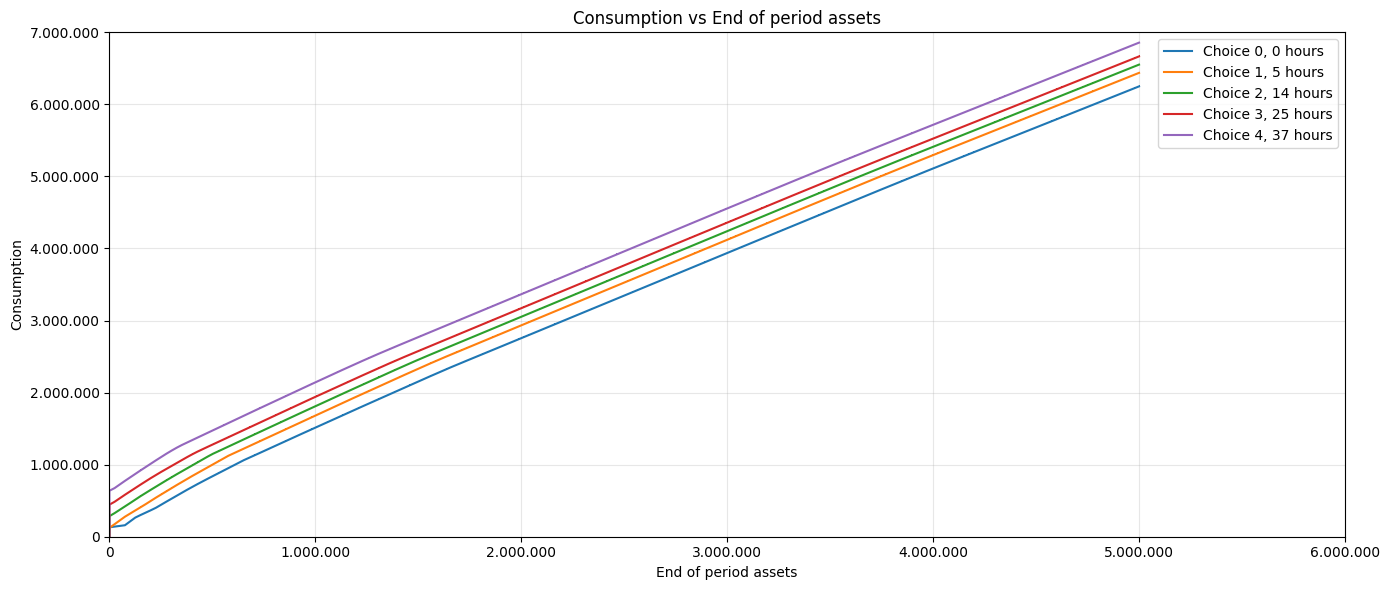

In [79]:
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(14, 6))

for choice, hours in hours_map.items():
    d = p20lc3s1exp4[p20lc3s1exp4["current_choice"] == choice].copy()
    d = d.sort_values("assets_end_of_period")
    d["assets_end_of_period_scaled"] = d["assets_end_of_period"] * 100000
    d["consumption_scaled"] = d["consumption"] * 100000
    d["resources_scaled"] = d["resources"] * 100000

    ax.plot(
        d["assets_end_of_period_scaled"],
        d["consumption_scaled"],
        marker=",",
        label=f"Choice {choice}, {hours/52 :.0f} hours",
    )

ax.set_xlabel("End of period assets")
ax.set_ylabel("Consumption")
ax.set_title("Consumption vs End of period assets")
ax.legend()
ax.set_xlim(0, 60 * 100000)
ax.set_ylim(0, 70 * 100000)
import matplotlib.ticker as mtick

ax.ticklabel_format(style="plain", axis="both")

ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", "."))
)

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda y, pos: f"{y:,.0f}".replace(",", "."))
)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

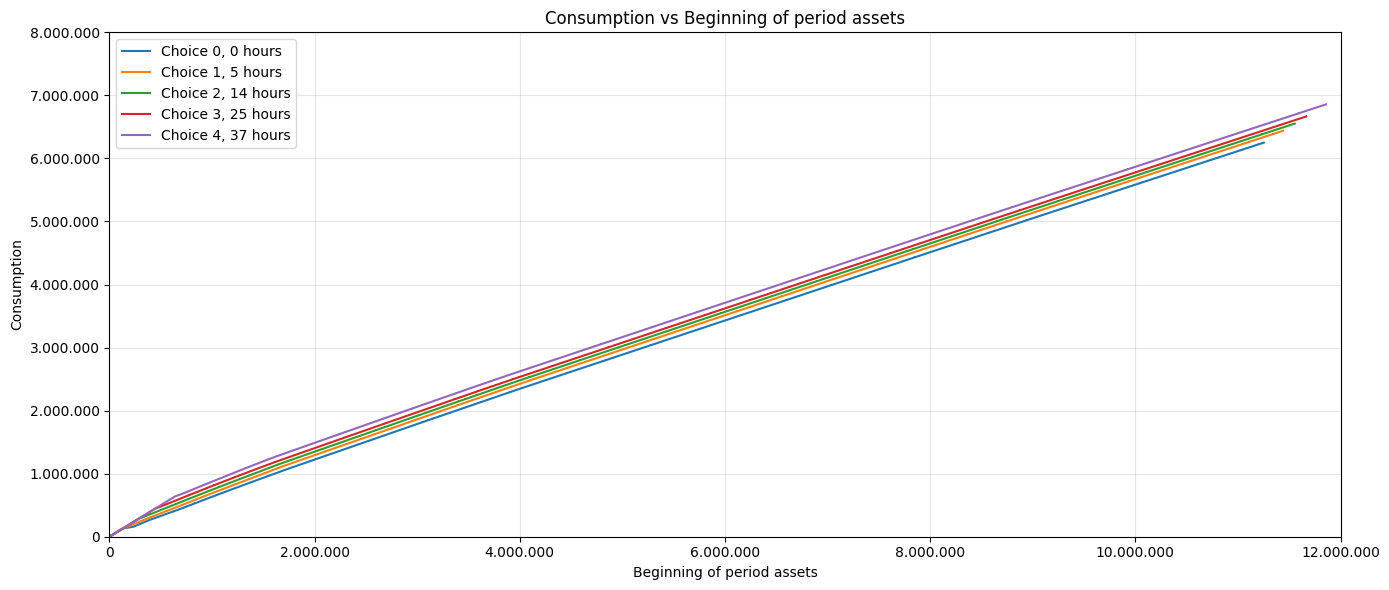

In [75]:
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(14, 6))

for choice, hours in hours_map.items():
    d = p20lc3s1exp4[p20lc3s1exp4["current_choice"] == choice].copy()
    d = d.sort_values("assets_end_of_period")
    d["assets_end_of_period_scaled"] = d["assets_end_of_period"] * 100000
    d["consumption_scaled"] = d["consumption"] * 100000
    d["resources_scaled"] = d["resources"] * 100000

    ax.plot(
        d["resources_scaled"],
        d["consumption_scaled"],
        marker=",",
        label=f"Choice {choice}, {hours/52 :.0f} hours",
    )

ax.set_xlabel("Beginning of period assets")
ax.set_ylabel("Consumption")
ax.set_title("Consumption vs Beginning of period assets")
ax.legend()
ax.set_xlim(0, 120 * 100000)
ax.set_ylim(0, 80 * 100000)
import matplotlib.ticker as mtick

ax.ticklabel_format(style="plain", axis="both")

ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", "."))
)

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda y, pos: f"{y:,.0f}".replace(",", "."))
)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

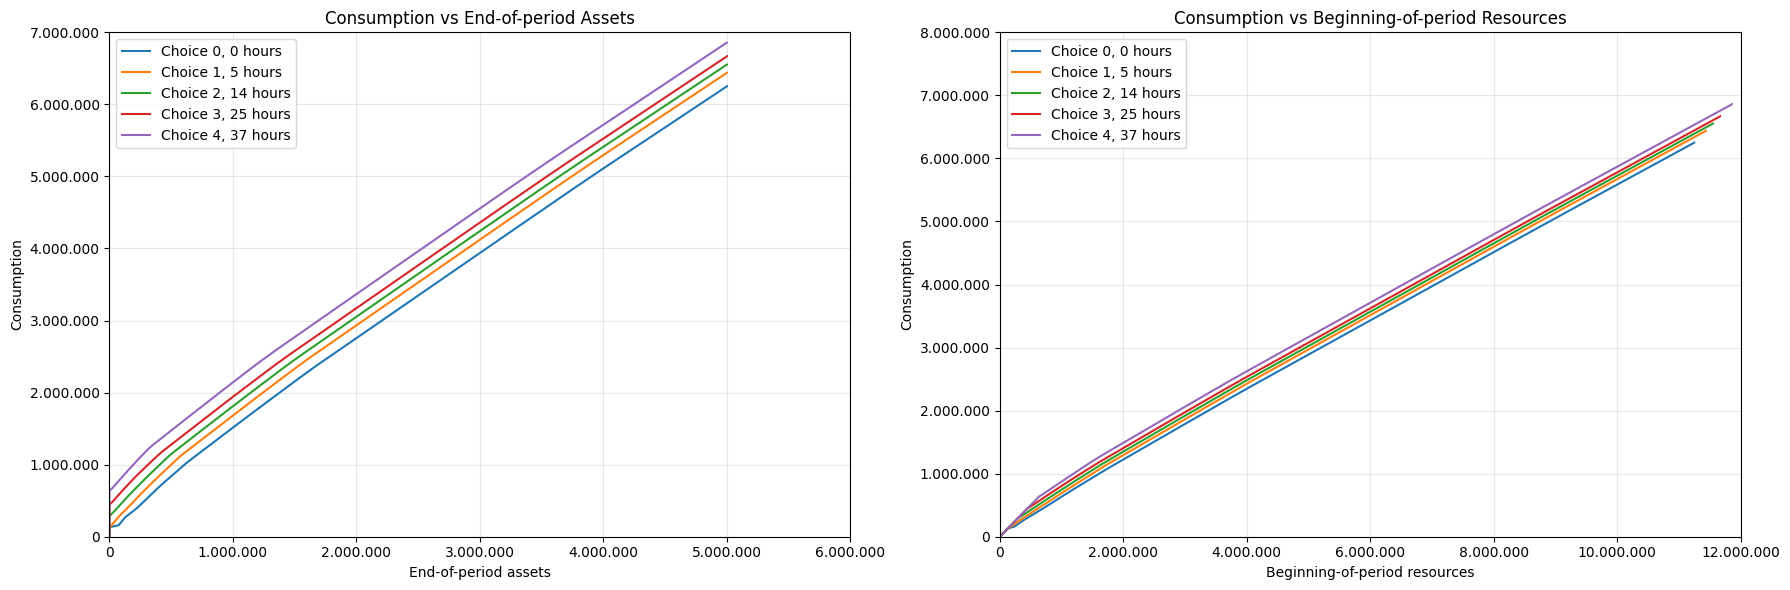

In [80]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

formatter = mtick.FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", "."))

for choice, hours in hours_map.items():
    d = p20lc3s1exp4[p20lc3s1exp4["current_choice"] == choice].copy()
    d = d.sort_values("assets_end_of_period")

    d["assets_end_of_period_scaled"] = d["assets_end_of_period"] * 100000
    d["consumption_scaled"] = d["consumption"] * 100000
    d["resources_scaled"] = d["resources"] * 100000

    label = f"Choice {choice}, {hours / 52:.0f} hours"

    # Left plot: consumption vs end-of-period assets
    axes[0].plot(
        d["assets_end_of_period_scaled"],
        d["consumption_scaled"],
        marker=",",
        label=label,
    )

    # Right plot: consumption vs beginning-of-period resources
    axes[1].plot(
        d["resources_scaled"],
        d["consumption_scaled"],
        marker=",",
        label=label,
    )

# Left axis settings
axes[0].set_xlabel("End-of-period assets")
axes[0].set_ylabel("Consumption")
axes[0].set_title("Consumption vs End-of-period Assets")
axes[0].set_xlim(0, 60 * 100000)
axes[0].set_ylim(0, 70 * 100000)
axes[0].grid(alpha=0.3)

# Right axis settings
axes[1].set_xlabel("Beginning-of-period resources")
axes[1].set_ylabel("Consumption")
axes[1].set_title("Consumption vs Beginning-of-period Resources")
axes[1].set_xlim(0, 120 * 100000)
axes[1].set_ylim(0, 80 * 100000)
axes[1].grid(alpha=0.3)

# Formatting both plots
for ax in axes:
    ax.ticklabel_format(style="plain", axis="both")
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)
    ax.legend()

plt.tight_layout()
plt.show()